In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
inputs = [1,2,3]
weights = [0.2,0.4,0.9]
bias = 1

output = (inputs[0]*weights[0] + inputs[1]*weights[1] + inputs[2]*weights[2])+bias
print("Our First Neuron")
print(output)

Our First Neuron
4.7


In [3]:
inputs = [1,2,3,9]
weights = [0.2,0.4,0.9,-0.5]
bias = 2

output = (inputs[0]*weights[0] + 
          inputs[1]*weights[1] + 
          inputs[2]*weights[2]+ 
          inputs[3]*weights[3] +bias)

print("Neuron with 4 inputs & weights +bias")
print(output)

Neuron with 4 inputs & weights +bias
1.2000000000000002


### Layer Of Neuron

In [4]:
inputs = [2,4,5,3]
weights = [[0.8,0.7,-0.4,0.2],[0.1,0.3,0.4,-0.1],[-0.2,-0.3,-0.9,0.9]]
bias = [1,3,2] # b1,b2,b3

outputs = [
    # Layer 1:
    inputs[0]*weights[0][0] + 
    inputs[1]*weights[0][1] + 
    inputs[2]*weights[0][2]+ 
    inputs[3]*weights[0][3] +bias[0],
    # Layer 2:
    inputs[0]*weights[1][0] + 
    inputs[1]*weights[1][1] + 
    inputs[2]*weights[1][2]+ 
    inputs[3]*weights[1][3] +bias[1],
    # Layer 3:
    inputs[0]*weights[2][0] + 
    inputs[1]*weights[2][1] + 
    inputs[2]*weights[2][2]+ 
    inputs[3]*weights[2][3] +bias[2]
]

print(outputs)

[4.0, 6.1, -1.3999999999999995]


In [5]:
inputs = [2,4,5,3]
weights = [[0.8,0.7,-0.4,0.2],[0.1,0.3,0.4,-0.1],[-0.2,-0.3,-0.9,0.9]]
bias = [1,3,2] # b1,b2,b3

outputs = []

for neuron_weight,neuron_bias in zip(weights,bias):
    neuron_output = 0
    for n_input,n_weight in zip(inputs,neuron_weight):
        neuron_output += n_input*n_weight
    neuron_output += neuron_bias
    outputs.append(round(neuron_output, 2))

print(outputs)

[4.0, 6.1, -1.4]


## Dot Product

### Single Neuron

In [6]:
inputs = [1,2,3]
weights = [0.2,0.4,0.9]
bias = 1

output = np.dot(inputs,weights)+bias
print("Neuron using dot product")
print(output)

Neuron using dot product
4.7


### Layer Of Neuron

In [7]:
inputs = [2,4,5,3]
weights = [[0.8,0.7,-0.4,0.2],[0.1,0.3,0.4,-0.1],[-0.2,-0.3,-0.9,0.9]]
bias = [1,3,2] # b1,b2,b3

# outputs = np.dot(weights,inputs)+bias
outputs = np.dot(inputs,np.transpose(weights))+bias

# outputs = [np.dot(inputs,weights[0])+bias[0],np.dot(inputs,weights[1])+bias[1],np.dot(inputs,weights[2])+bias[2]]
print(outputs)

[ 4.   6.1 -1.4]


### Batch Of Data 

In [8]:
inputs = [[0.4,2,0.9,3.4],[1,2,3,4],[9,8,7,6]]
weights = [[0.8,0.7,-0.4,0.2],[0.1,0.3,0.4,-0.1],[-0.2,-0.3,-0.9,0.9]]
biases = [1,2,3]

# outputs = np.dot(weights,np.transpose(inputs))+biases
outputs = np.dot(inputs,np.transpose(weights))+biases
print(outputs)

[[ 3.04  2.66  4.57]
 [ 2.8   3.5   3.1 ]
 [12.2   7.5  -2.1 ]]


## Add more layers in neural network

In [9]:
inputs = [[0.4,2,0.9,3.4],
          [1,2,3,4],
          [9,8,7,6]]
weights1 = [[0.8,0.7,-0.4,0.2],
           [0.1,0.3,0.4,-0.1],
           [-0.2,-0.3,-0.9,0.9]]
biases1 = np.array([1,2,3])

weights2 = [[0.7,0.4,0.8],
           [0.9,0.7,-0.9],
           [0.2,0.3,-0.2]]
biases2 = np.array([2,3.4,2])

layer_output1 = np.dot(inputs,np.transpose(weights1))+biases1
print(layer_output1)

layer_output2 = np.dot(layer_output1,np.transpose(weights2))+biases2

print(layer_output2)

[[ 3.04  2.66  4.57]
 [ 2.8   3.5   3.1 ]
 [12.2   7.5  -2.1 ]]
[[ 8.848  3.885  2.492]
 [ 7.84   5.58   2.99 ]
 [11.86  21.52   7.11 ]]


### Generating Non-linear Training Data

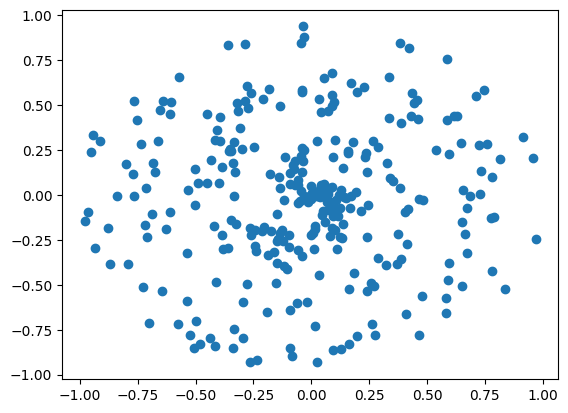

In [10]:
from nnfs.datasets import spiral_data
import nnfs
nnfs.init()
X,y = spiral_data(samples=100,classes=3)
plt.scatter(X[:,0],X[:,1])
plt.show()

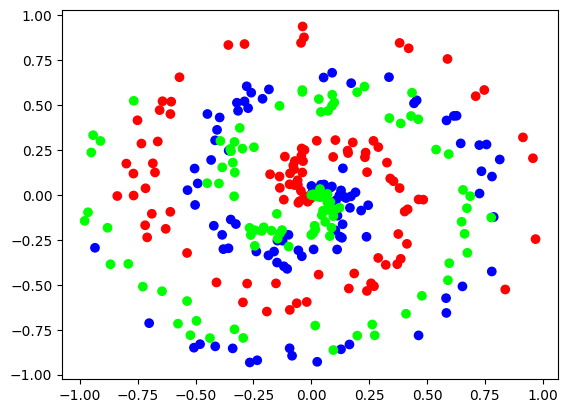

In [11]:
plt.scatter(X[:,0],X[:,1],c=y,cmap='brg')
plt.show()

In [12]:
class layer_dense:
    # layer initialization
    def __init__(self,n_inputs,n_neurons):
        # initializa the weights and biases
        self.weights = 0.01*np.random.randn(n_inputs,n_neurons)
        self.biases = np.zeros((1,n_neurons))
    
    # Forward Pass
    def forward(self,inputs):
        # calculate the output value from the input,weight and bias
        self.output = np.dot(inputs,self.weights) + self.biases
        
# create dataset
X,y = spiral_data(samples=100,classes=3)

# create a layer with input and neuron
dense1 = layer_dense(2,3)
dense1.forward(X)
print(dense1.output[:5])

[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-1.11171044e-04 -5.11007493e-05 -1.12099799e-04]
 [ 2.99257295e-06 -2.69126613e-04 -1.45165104e-04]
 [ 8.95101766e-05 -4.30442247e-04 -1.68079801e-04]
 [-3.49893759e-04 -3.07208364e-04 -4.33002861e-04]]


### ReLu Activation Function

In [13]:
inputs = [0,2,3,-3.4,-0.4,4,2]
output = np.maximum(0,inputs)
print(output)

[0. 2. 3. 0. 0. 4. 2.]


In [14]:
class Activation_ReLu:
    # Forward Pass
    def forward(self,inputs):
        self.output = np.maximum(0,inputs)

In [15]:
# create dataset
X,y = spiral_data(samples=100,classes=3)

# create a layer with input and neuron
dense1 = layer_dense(2,3)
activation1 = Activation_ReLu()
dense1.forward(X)
activation1.forward(dense1.output)
print(activation1.output[:5])

[[0.0000000e+00 0.0000000e+00 0.0000000e+00]
 [1.3520580e-04 1.8173116e-05 0.0000000e+00]
 [2.3245417e-04 0.0000000e+00 0.0000000e+00]
 [3.8226307e-04 0.0000000e+00 0.0000000e+00]
 [5.7436468e-04 0.0000000e+00 0.0000000e+00]]


### Broadcasting in Python

In [16]:
inputs = [[2,4,6],[3,6,9],[4,8,12]]
print(np.sum(inputs,axis=0))
print(np.sum(inputs,axis=0).shape)
print(np.sum(inputs,axis=0))
print(np.sum(inputs,axis=0,keepdims=True).shape)
print('')
max_input = np.max(inputs,axis=1,keepdims=True)
print(max_input)
outputs = inputs+max_input
print(outputs)

[ 9 18 27]
(3,)
[ 9 18 27]
(1, 3)

[[ 6]
 [ 9]
 [12]]
[[ 8 10 12]
 [12 15 18]
 [16 20 24]]


### Softmax Activation

In [17]:
inputs = [[1,2,3,2.5],
         [2,5,-1,2],
         [-1.5,2.7,3.3,-0.8]]

# get unnormalized probabilities
exp_values = np.exp(inputs - np.max(inputs,axis=1,keepdims=True))
# Normalize for each samples
probabilities = exp_values / np.sum(exp_values,axis=1,keepdims=True)
print(probabilities)
np.sum(probabilities,axis=1)

[[0.06414769 0.17437149 0.47399085 0.28748998]
 [0.04517666 0.90739747 0.00224921 0.04517666]
 [0.00522984 0.34875873 0.63547983 0.0105316 ]]


array([1., 1., 1.])

In [18]:
class Activation_softmax:
    # forward pass
    def forward(self,inputs):
        # get unnormalized probabilities
        exp_values = np.exp(inputs - np.max(inputs,axis=1,keepdims=True))
        # Normalize for each samples
        probabilities = exp_values / np.sum(exp_values,axis=1,keepdims=True)
        self.output = probabilities

In [20]:
# create dataset
X,y = spiral_data(samples=100,classes=3)

# create a layer with input and neuron
dense1 = layer_dense(2,3)
# Create a ReLu activation use with dense layer
activation1 = Activation_ReLu()
# create a dense layer with the input of the previous layer and 3 output values
dense2 = layer_dense(3,3)
# create softmax activation, to be used with dense layer
softmax1 = Activation_softmax()
# fowrad pass of our training data through this layer
dense1.forward(X)
# make a forward pass through Activation function
# it takes the output of the first dense layer
activation1.forward(dense1.output)
# forward pass through the second dense layer, it takes output from activation function from prev layer
dense2.forward(activation1.output)
# make a forward pass through the second activation function (softmax) function
# it takes the output of the previous dense layer
softmax1.forward(dense2.output)
print(softmax1.output[:5])
# print(np.sum(softmax1.output,axis=1))

[[0.33333334 0.33333334 0.33333334]
 [0.3333327  0.33333316 0.33333412]
 [0.33333313 0.33333328 0.3333336 ]
 [0.33333334 0.33333334 0.33333334]
 [0.33333334 0.33333334 0.33333334]]


### Cross-Entropy Loss

In [25]:
softmax_output = np.array([[0.7,0.1,0.2],
                 [0.1,0.5,0.4],
                 [0.02,0.9,0.08]])
class_target = [0,1,1]
print(softmax_output[[0,1,2],class_target])

[0.7 0.5 0.9]


In [29]:
neg_loss = -np.log(softmax_output[range(len(softmax_output)),class_target])
print(neg_loss)
avg_loss = np.mean(neg_loss)
print(avg_loss)

[0.35667494 0.69314718 0.10536052]
0.38506088005216804


### Implementing the cross-entropy class

In [30]:
class Loss:
    def calculate(self,output,y):
        # calculate sample losses
        sample_losses = self.forward(output,y)
        data_loss = np.mean(sample_losses)
        return data_loss

In [49]:
# Cross-entropy loss
class Loss_CategoricalCrossentropy(Loss):
 # Forward pass
 def forward(self, y_pred, y_true):
  # Number of samples in a batch
  samples = len(y_pred)
  # Clip data to prevent division by 0
  # Clip both sides to not drag mean towards any value
  y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)
  # Probabilities for target values -
  # only if categorical labels
  if len(y_true.shape) == 1:
   correct_confidences = y_pred_clipped[
   range(samples),
   y_true
   ]
  # Mask values - only for one-hot encoded labels
  elif len(y_true.shape) == 2:
   correct_confidences = np.sum(
   y_pred_clipped*y_true,
   axis=1
   )
 # Losses
  negative_log_likelihoods = -np.log(correct_confidences)
  return negative_log_likelihoods

In [44]:
softmax_output = np.array([[0.7, 0.1, 0.2],
 [0.1, 0.5, 0.4],
 [0.02, 0.9, 0.08]])
# One-hot encoded class targets
class_targets = np.array([[1, 0, 0],
 [0, 1, 0],
 [0, 1, 0]])
loss_function = Loss_categoricalcross_entropy()
loss = loss_function.calculate(softmax_output,class_targets)
print(loss)

0.38506088005216804


## The Need for Optimization

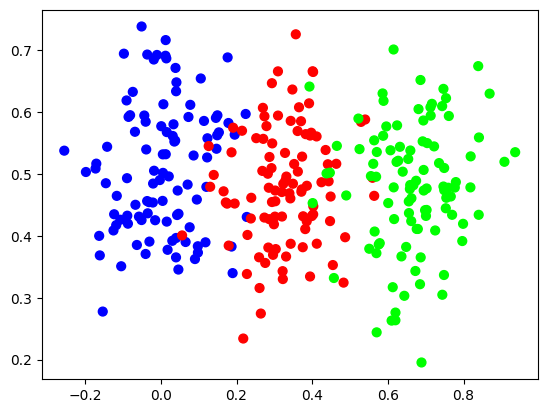

In [50]:
#SIMPLER DATASET
import matplotlib.pyplot as plt
import nnfs
from nnfs.datasets import vertical_data
nnfs.init()
X, y = vertical_data(samples=100, classes=3)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap='brg')
plt.show()